In [18]:
%load_ext autoreload
%autoreload 2

In [22]:
import equinox as eqx
import esm  # pip install fair-esm==2.0.0
import esm2quinox
import jax.random as jrandom
import optax  # pip install optax
from dataset import initialize_datasets, test
from model import AFF_PREDICTOR, Prediction_Head
from training import train_model, eval_step
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import jax.random as jr
import jax

In [4]:
# initialize the dataloader
train_loader, val_loader, test_loader = initialize_datasets(
    paths=[
        "/home/jkunz/master_uni_hd/internship_amsterdam/BindCraft_uva_internship/data/train.csv",
        "/home/jkunz/master_uni_hd/internship_amsterdam/BindCraft_uva_internship/data/validation.csv",
        "/home/jkunz/master_uni_hd/internship_amsterdam/BindCraft_uva_internship/data/test.csv",
    ],
    batches=[5, 3, 1],
)

In [34]:
# generating keys
model_key, call_key= jr.split(jrandom.PRNGKey(0), 2)
call_key_batched = jr.split(call_key, 5)
# initializing models
torch_model, _ = esm.pretrained.esm2_t6_8M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)
model_aff, state = eqx.nn.make_with_state(AFF_PREDICTOR)(
    model=model_esm2, key=model_key
)

# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(model_aff, eqx.is_inexact_array))


In [40]:

# train model
best_model, best_state, train_losses, val_losses = train_model(
    training_DataLoader=train_loader,
    validation_Dataloader=val_loader,
    max_epochs=2,
    model_aff=model_aff,
    key= call_key,
    opt_state=opt_state,
    optim=optim,
)

Epochs:   0%|          | 0/2 [00:00<?, ?it/s]

Epochs:   0%|          | 0/2 [08:17<?, ?it/s]


KeyboardInterrupt: 

In [3]:
inference_model = eqx.nn.inference_mode(best_model)
inference_model = eqx.Partial(inference_model, state=best_state)
test_loss_list = []

for entry, (x_val, y_val) in enumerate(test_loader):
    x_val, y_val = jnp.array(x_val), jnp.array(y_val)
    test_loss, pred_y = eval_step(inference_model, x_val, y_val)
    test_loss_list.append(test_loss.item())


    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.6f}, Predicted Y: {pred_y.item():.6f}, , True Y: {y_val.item():.6f}"
    )


[Entry 1] , Test Loss: 0.065856, Predicted Y: 0.248743, , True Y: 0.505367
[Entry 2] , Test Loss: 0.016682, Predicted Y: 0.253648, , True Y: 0.382808
[Entry 3] , Test Loss: 0.042441, Predicted Y: 0.247773, , True Y: 0.453784
[Entry 4] , Test Loss: 0.093420, Predicted Y: 0.235696, , True Y: 0.541342
[Entry 5] , Test Loss: 0.082488, Predicted Y: 0.258706, , True Y: 0.545913
[Entry 6] , Test Loss: 0.077859, Predicted Y: 0.249420, , True Y: 0.528453
[Entry 7] , Test Loss: 0.218737, Predicted Y: 0.245512, , True Y: 0.713205
[Entry 8] , Test Loss: 0.115143, Predicted Y: 0.254479, , True Y: 0.593806
[Entry 9] , Test Loss: 0.019515, Predicted Y: 0.264105, , True Y: 0.403799
[Entry 10] , Test Loss: 0.130656, Predicted Y: 0.255729, , True Y: 0.617192
[Entry 11] , Test Loss: 0.108379, Predicted Y: 0.253165, , True Y: 0.582374
[Entry 12] , Test Loss: 0.045518, Predicted Y: 0.245922, , True Y: 0.459271
[Entry 13] , Test Loss: 0.034872, Predicted Y: 0.245541, , True Y: 0.432282
[Entry 14] , Test Los

In [15]:
y_train = []
for x,y in train_loader:
    y_train.append(y)
    

In [27]:
y_all = []
for y in y_train:
    y_all.extend(np.array(y.flatten()))

/tmp/ipykernel_406096/2146560178.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_all.extend(np.array(y.flatten()))


In [28]:
y_all

[np.float64(0.4069616835782524),
 np.float64(0.4069616835782524),
 np.float64(0.9010508577242694),
 np.float64(0.8000967927132779),
 np.float64(0.5538909499477096),
 np.float64(0.3689813300279721),
 np.float64(0.5053665428679168),
 np.float64(0.3828079044711987),
 np.float64(0.3994695867475277),
 np.float64(0.6338537778051306),
 np.float64(0.6653192421932691),
 np.float64(0.7264684424683591),
 np.float64(0.44894415788539316),
 np.float64(0.6120487959478913),
 np.float64(0.7710305728610859),
 np.float64(0.7376429506492244),
 np.float64(0.7376429506492244),
 np.float64(0.7376429506492244),
 np.float64(0.49996958344027254),
 np.float64(0.5459125425336969),
 np.float64(0.5459125425336969),
 np.float64(0.5854195853931574),
 np.float64(0.654845014958701),
 np.float64(0.5459125425336969),
 np.float64(0.5392341904066411),
 np.float64(0.5392341904066411),
 np.float64(0.8064312703257802),
 np.float64(0.567717524390936),
 np.float64(0.7161412378045321),
 np.float64(0.7161412378045321),
 np.float6

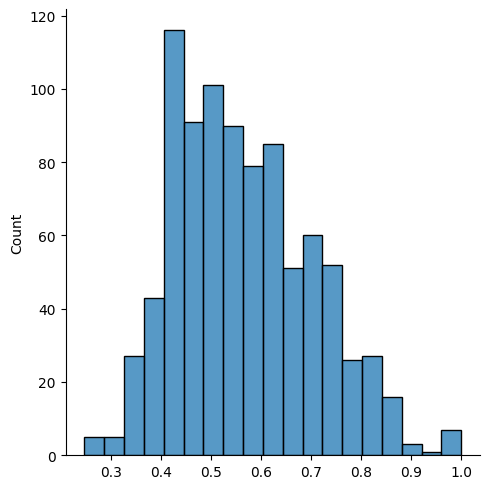

In [29]:
sns.displot(y_all)